In [ ]:
import pickle
from FlyOutput import FlyOutput
import Plotters
import plotly.graph_objects as go
import numpy as np  
import Utils
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
from Evaluation import Evaluation
import time
import pandas as pd

%matplotlib qt

frame_num = 370
cam = 0
image_path = 'D:/Documents/data_for_gs/mov1_2023_08_09_60ms/'
dict_path  = 'D:/Documents/data_for_gs/mov1_2023_08_09_60ms/dict/frames_model.pkl'
path_output = 'D:/Documents/gaussian_model_output/'
interest_point_h5_path = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/evalutation'
input_path_for_image = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/'

image_path = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/mov128_2023_08_09_60ms/'
dict_path  = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/evaluation/dict/frames_model_evaluation.pkl'
# path_output = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_output/'

# image_path = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/mov30_2024_11_12_darkan/'
# dict_path  = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/mov30_2024_11_12_darkan/frames_model_evaluation.pkl'
# path_output = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_output/'

model_name = 'fly_features_compare'
file_name = 'fly_model'


model_name = 'fly_features_dense'
file_name = 'fly_model'

idx_iter = 0
model_name = 'fly_roll_sweep_m15_15'
file_name = f'fly_model_scale_iter{idx_iter}'


idx_iter = 0
model_name = 'fly_pitch_sweep_m15_15'
file_name = f'fly_model_scale_iter{idx_iter}'

idx_iter = 0
model_name = 'fly_pitch_delta10_sweep_m40_40'
file_name = f'fly_model_scale_iter{idx_iter}'

input_dir = f'{path_output}/{model_name}'

# delta_angles = np.hstack((0,np.arange(-15.0,0,5),np.arange(5.0,15,5)))
# angle_name = 'roll'

delta_angles = np.hstack((0,np.arange(-20.0,0,5),np.arange(5.0,25,5)))
angle_name = 'psi right'

delta_angles =  np.hstack((0,np.arange(-40.0,0,10),np.arange(10.0,60,10)))
angle_name = 'theta right'



with open(dict_path,'rb') as f:
    frames = pickle.load(f)


input_dir_ini = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/evaluation'

with open(f'{input_dir_ini}/nominal_initial_angles.pkl', 'rb') as handle:
    nominal_initial_angles = pickle.load(handle)

def open_file(path,ang_dict = {}):
    with open(path,'rb') as f:
        ini_angles = pickle.load(f)
    ang_dict = {ang_name: angles for ang_name,angles in ini_angles.items()}
    return ang_dict


dirs = os.listdir(f'{input_dir}/{list(nominal_initial_angles.keys())[0].split("_")[3]}') 
sweep_size = len([dir for dir in dirs if 'fly' in dir.split('_')])



mov_name = list(nominal_initial_angles.keys())[1]
mov = int(mov_name.split('_')[1]) 
frame = int(mov_name.split('_')[3]) 
path = f'D:/Documents/gaussian_model_output/{model_name}/{frame}/initial/'
dir_names = [name for name in os.listdir(path) if os.path.isfile(os.path.join(path, name))]
ini_angles = {idx:open_file(f'{path}/{dir}') for idx,dir in enumerate(dir_names)}


[angles['left_wing_angles'] for angles in ini_angles.values()]


from EvaluateAngleSweep import EvaluateAngleSweep
sweep_eval = EvaluateAngleSweep(frames,nominal_initial_angles,input_dir, path)

[[-49.0, -74.0, 7.0],
 [-49.0, -74.0, 7.0],
 [-49.0, -74.0, 7.0],
 [-49.0, -74.0, 7.0],
 [-49.0, -74.0, 7.0],
 [-49.0, -74.0, 7.0],
 [-49.0, -74.0, 7.0],
 [-49.0, -74.0, 7.0],
 [-49.0, -74.0, 7.0]]

In [ ]:
sweep_eval = EvaluateAngleSweep(frames,nominal_initial_angles,input_dir, path)
iteration = 1000
sweep_path = f'{input_dir}/frames_{angle_name}_sweep_iteration_{iteration}.pkl'

sweep_eval.load_sweep(sweep_path,file_path_save_hull)

In [ ]:
phi =np.vstack([angles['left_wing_angles'] for angles in ini_angles.values()])[:,0]
-phi[0]+ phi

KeyError: 'theta right'

In [5]:
import pickle
import numpy as np
input_dir_ini = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/evaluation'

with open(f'{input_dir_ini}/nominal_initial_angles.pkl', 'rb') as handle:
    nominal_initial_angles = pickle.load(handle)


body_ang = np.vstack([nominal_initial_angles['body_angles'] for nominal_initial_angles in nominal_initial_angles.values()])
lw_ang = np.vstack([nominal_initial_angles['left_wing_angles'] for nominal_initial_angles in nominal_initial_angles.values()])
rw_ang = np.vstack([nominal_initial_angles['right_wing_angles'] for nominal_initial_angles in nominal_initial_angles.values()])

In [20]:

%matplotlib qt

plt.scatter(body_ang[:,0],lw_ang[:,0])

bins = np.vstack([body_ang[:,0],lw_ang[:,0],rw_ang[:,0]])

In [32]:
np.diff(lw_ang[:,0])

array([  10.,   10.,   14.,    9.,   17.,    7.,   16.,    8.,   15.,
          9.,   13.,  -10.,   22., -142.,   13.,   10.,   14.,    9.,
         16.,    8.,   15.,    9.,   16.,    9.,   18.,    7., -145.,
         13.,    9.,   14.,   10.,   17.,    6.,   17.,    6.,   17.,
          9.,   14.,   -8., -125.,   15.,   -9.,   16.,   18.,  -12.,
         18.,   17.,   -8.,   15.,   16.,   -8.,   16.,   16.,   -8.,
         16.,   15.,   -9.,   16., -138.,   13.,  -10.,   16.,   19.,
          6.,   19.,   -9.,   15.,   17.,    6.,   16.,  -10.,   18.,
         15.,  -10.,   17., -149.,   10.,   13.,   -8.,   16.,   17.,
         -9.,   15.,   21.,  -11.,   15.,   19.,  -10.,   16.,   16.,
          9.,   13.,  -10.,   14., -148.,   10.,   14.,  -12.,   21.,
         16.,  -11.,   18.,   19.,  -10.,   17.,   16.,   -9.,   17.,
         15.,  -10.,   19.,   13.,   -9.,   17., -100.,  -39.,   19.,
         16.,   -9.,   17.,   15.,   -8.,   16.,   17.,  -10.,   19.,
         17.,  -11.,

In [31]:
import plotly.graph_objects as go
fig = go.Figure()
Plotters.scatter3d(fig,bins.T,'lime',4,'right wing boundary te',show_colorbar = False,mode=' markers')
fig.show()


(array([27.,  0., 13., 19., 17., 19., 20., 17.,  9., 11.]),
 array([ 10. ,  20.5,  31. ,  41.5,  52. ,  62.5,  73. ,  83.5,  94. ,
        104.5, 115. ]),
 <BarContainer object of 10 artists>)

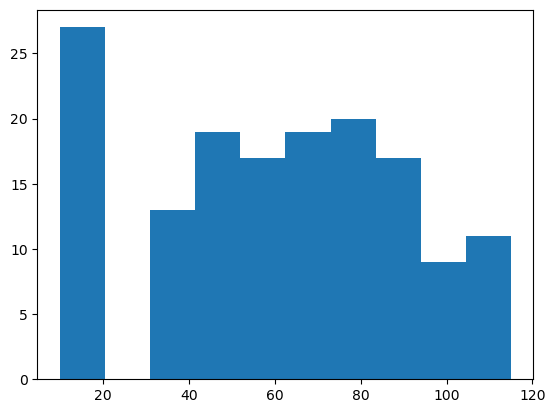

In [ ]:
import matplotlib.pyplot as plt

plt.hist(body_ang[:,0])

In [16]:
[int(nominal_initial_angles.split('_')[-1]) for nominal_initial_angles in nominal_initial_angles if nominal_initial_angles.split('_')[-1] == 1650]

[]

In [2]:
# load model frames and hull



letedict = {'num_of_bins' : 10,'perc_wing_for_le' : 1, 'wing_length_snip':0.25}
iteration = 1000
idx_iter = 9
all_frames = []
file_path = f'{input_dir}/frames_yaw_sweep_iteration_{iteration}.pkl'
file_path_save_hull = f'D:/Documents/gaussian_model_output/fly_yaw_sweep_m20_20/hull_body.pkl'


def load_frame_all_sweep(idx_iter,mov_name,iteration,letedict,frames):
    mov = int(mov_name.split('_')[1]) 
    frame0 = int(mov_name.split('_')[3]) 
    image_path =  f'{input_path_for_image}/mov{mov}_2023_08_09_60ms/'
    file_name = f'fly_model_scale_iter{idx_iter}'
    interest_points_path = f'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/evaluation/points/mov{mov}'
    
    with open(f'{input_dir}/results/{frame0}/{file_name}_results.pkl', 'rb') as handle:
        output_angles_weights = pickle.load(handle)
    
    frame_eval = Evaluation(interest_points_path,image_path,frame0,input_dir,output_angles_weights,frame0,iteration,file_name,letedict = letedict,frames_dict = frames)
    for source_attr, target_attr, output_attr in frame_eval.projection_tasks:
        frame_eval.get_projected_and_store(frame_eval, source_attr, target_attr, output_attr)
    return frame_eval



# generate frames file if it doesnt exist
if os.path.isfile(file_path):
    with open(file_path, "rb") as input_file:
       all_movs = pickle.load(input_file)
else:
    all_movs = {}
    from tqdm import tqdm
    for mov_name in tqdm(list(nominal_initial_angles.keys())[1:]):
        try:
            all_movs[mov_name] = [load_frame_all_sweep(idx_iter,mov_name,iteration,letedict,frames) for idx_iter in range(sweep_size)]        
        except:
            continue

# calculate errors
for mov_name in tqdm(list(all_movs.keys())[1:]):
        [frame.calculate_chamfler() for frame in all_movs[mov_name]]  

Utils.pickle_file(all_movs,file_path)
print(f'frames saved: {file_path}')


# generate hull file if it doesnt exist (body hull for ground truth)
if os.path.isfile(file_path_save_hull):
    with open(file_path_save_hull, "rb") as input_file:
       hull_movs = pickle.load(input_file)
else:
    Utils.make_body_hull_file(nominal_initial_angles,file_path_save_hull)

zbuff_hull = {movname: Utils.load_body_hull_calc_xbody(all_movs[movname][0], hull_movs[movname]) for movname in tqdm(list(all_movs.keys())[1:])}
dot_vec = [[frame.load_hull_calc_xbody_dot_per_idx(zbuff_hull[mov_name]) for frame in all_movs[mov_name]] for mov_name in tqdm(list(all_movs.keys())[1:])]


100%|██████████| 149/149 [00:03<00:00, 38.18it/s]


frames saved: D:/Documents/gaussian_model_output//fly_pitch_delta10_sweep_m40_40/frames_yaw_sweep_iteration_1000.pkl


100%|██████████| 149/149 [00:06<00:00, 23.10it/s]


In [5]:
delta_angles = np.array([  0., -40., -30., -20., -10.,  10.,  20.,  30.,  40.])




In [ ]:


# Calculate chamfer distance for wings and body
file_path = f'{input_dir}/chamfer.pkl'

if os.path.isfile(file_path):
    with open(file_path, "rb") as input_file:
        chamfer = pickle.load(input_file)

else:
    chamfer_2d_wing = np.vstack([[frame.error_2d_chamfer for frame in all_movs[mov_name]] for mov_name in list(all_movs.keys())[1:]]) /2
    chamfer_stats_2d_wing = Utils.get_camfer_stats(angle_name,delta_angles,chamfer_2d_wing)

    chamfer_3d_wing = np.vstack([[frame.error_3d_chamfer for frame in all_movs[mov_name]] for mov_name in list(all_movs.keys())[1:]])*1000/2
    chamfer_stats_3d_wing = Utils.get_camfer_stats(angle_name,delta_angles,chamfer_3d_wing)

    chamfer_3d_body = np.vstack([[frame.calculate_chamfler_body() for frame in all_movs[mov_name]] for mov_name in tqdm(list(all_movs.keys())[1:])])
    chamfer_stats_3d_body = Utils.get_camfer_stats(angle_name,delta_angles,chamfer_3d_body)

    chamfer_2d_body = np.vstack([[frame.calculate_chamfler_body_2d() for frame in all_movs[mov_name]] for mov_name in tqdm(list(all_movs.keys())[1:])])
    chamfer_stats_2d_body = Utils.get_camfer_stats(angle_name,delta_angles,chamfer_2d_body)


    chamfer_dict_wing = {'chamfer_2d':[chamfer_2d_wing,chamfer_stats_2d_wing],'chamfer_3d':[chamfer_3d_wing,chamfer_stats_3d_wing]}
    chamfer_dict_body = {'chamfer_2d':[chamfer_2d_body,chamfer_stats_2d_body],'chamfer_3d':[chamfer_3d_body,chamfer_stats_3d_body]}
    chamfer = {'wing': chamfer_dict_wing,'body':chamfer_dict_body}


    Utils.pickle_file(chamfer,file_path)
    print(f'frames saved: {file_path}')


  0%|          | 0/149 [00:00<?, ?it/s]

100%|██████████| 149/149 [01:25<00:00,  1.75it/s]


In [7]:

chamfer_dict_wing = {'chamfer_2d':[chamfer_2d_wing,chamfer_stats_2d_wing],'chamfer_3d':[chamfer_3d_wing,chamfer_stats_3d_wing]}
chamfer_dict_body = {'chamfer_2d':[chamfer_2d_body,chamfer_stats_2d_body],'chamfer_3d':[chamfer_3d_body,chamfer_stats_3d_body]}
chamfer = {'wing': chamfer_dict_wing,'body':chamfer_dict_body}

file_path = f'{input_dir}/chamfer.pkl'

Utils.pickle_file(chamfer,file_path)
print(f'frames saved: {file_path}')



frames saved: D:/Documents/gaussian_model_output//fly_pitch_delta10_sweep_m40_40/chamfer.pkl


In [6]:
path_figures = 'G:/My Drive/Research/gaussian_splatting/article/plots/evaluation/'
Plotters.plot_chamfer_frames_th(angle_name,chamfer_3d_wing,chamfer_stats_3d_wing,np.arange(0.01*1000,1*1000,5))
plt.savefig(f'{path_figures}{angle_name}_3d_frames_th_wings', transparent=True, dpi='figure', format='svg')

Plotters.plot_chamfer_frames_th(angle_name,chamfer_2d_wing,chamfer_stats_2d_wing,np.arange(0.1,2,0.01))
plt.savefig(f'{path_figures}{angle_name}_2d_frames_th_wings', transparent=True, dpi='figure', format='svg')

Plotters.boxplot(delta_angles,chamfer_3d_wing,angle_name,showfliers = True)
plt.savefig(f'{path_figures}{angle_name}_box_plot_wings', transparent=True, dpi='figure', format='svg')



NameError: name 'pd' is not defined

In [ ]:

Plotters.plot_chamfer_frames_th(angle_name,chamfer_3d_body*1000,chamfer_stats_3d_body,np.arange(0.01*1000,1*1000,5))
plt.savefig(f'{path_figures}{angle_name}_3d_frames_th_body', transparent=True, dpi='figure', format='svg')

Plotters.plot_chamfer_frames_th(angle_name,chamfer_2d_body,chamfer_stats_2d_body,np.arange(0.1,5,0.01))
plt.savefig(f'{path_figures}{angle_name}_2d_frames_th_body', transparent=True, dpi='figure', format='svg')

Plotters.boxplot(delta_angles,chamfer_3d_wing,angle_name,showfliers = True)
plt.savefig(f'{path_figures}{angle_name}_box_plot_body', transparent=True, dpi='figure', format='svg')




In [44]:
hull_to_compare = {}
pth = 'D:/Documents/gaussian_model_output/hull_evaluation'
input_path_for_image = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/'

with open(f'{pth}/hull_files.txt', 'r') as f:
    mov_hull_ini = [line.strip() for line in f]
mov_frame = [(int(mov_name.split('_')[1]),int(mov_name.split('_')[3])) for mov_name in mov_hull_ini]

hull_to_compare = {mov_name: FlyOutput(f'{input_path_for_image}/mov{mov_frame[0]}_2023_08_09_60ms/',mov_frame[1],f'{pth}/',None,mov_frame[1],iteration,f'',frames_dict = frames) for mov_frame,mov_name in zip(mov_frame,mov_hull_ini)}
zbuff_hull = [all_movs[mov_name][0].homog_and_zbuff( hull_to_compare[mov_name].xyz) for mov_name in mov_hull_ini]
zbuff_model = [all_movs[mov_name][0].homog_and_zbuff( all_movs[mov_name][0].xyz) for mov_name in mov_hull_ini]


for mov_name in mov_hull_ini:
    hull_to_compare[mov_name].zbuff_hull = all_movs[mov_name][0].homog_and_zbuff( all_movs[mov_name][0].xyz)

for mov_name in mov_hull_ini:
    all_movs[mov_name][0].zbuff_all = all_movs[mov_name][0].homog_and_zbuff( hull_to_compare[mov_name].xyz)




In [120]:
[mov for idx,mov in enumerate(list(nominal_initial_angles.keys())) if mov not in list(all_movs.keys())]

['mov_128_frame_1620',
 'mov_78_frame_1708',
 'mov_27_frame_695',
 'mov_59_frame_1990',
 'mov_94_frame_1675',
 'mov_91_frame_3362',
 'mov_56_frame_4245',
 'mov_56_frame_4225',
 'mov_59_frame_2364',
 'mov_56_frame_3665',
 'mov_56_frame_4230',
 'mov_56_frame_5853']

In [119]:
[idx for idx,mov in enumerate(list(nominal_initial_angles.keys())) if mov not in list(all_movs.keys())]

[0, 92, 140, 143, 150, 157, 158, 159, 160, 161, 162, 163]

In [72]:
# load output of gs with hull initialization
iteration = 2000
path = 'D:/Documents/gaussian_model_output/hull_evaluation'
hull_to_compare = {}
for mov_name in tqdm(list(nominal_initial_angles.keys())):
    try:
        mov = int(mov_name.split('_')[1]) 
        frame = int(mov_name.split('_')[3]) 
        image_path =  f'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/mov{mov}_2023_08_09_60ms/'
        file_name = f''
        output_angles_weights = None
        interest_points_path = f'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/evaluation/points/mov{mov}'
        input_dir = f'{path}/'
        hull_to_compare[mov_name] = FlyOutput(image_path,frame,input_dir,output_angles_weights,frame,iteration,file_name,frames_dict = frames)
        hull_to_compare[mov_name].zbuff_hull = all_movs[mov_name][0].homog_and_zbuff( hull_to_compare[mov_name].xyz)
        all_movs[mov_name][0].zbuff_all = all_movs[mov_name][0].homog_and_zbuff( all_movs[mov_name][0].xyz)
    except:
        continue

100%|██████████| 164/164 [00:20<00:00,  8.07it/s]


In [79]:
# compare wing_


def get_dist_ptclouds(points1,points2):
    closest_to_hull_body = Utils.find_closest_points_inptclouds(points1,points2)
    return np.sqrt(np.sum((closest_to_hull_body - points1)**2, axis = 1))


def get_wing_body_from_hull(hull_points,gt_body,gt_wing):

    closest_to_hull_body = get_dist_ptclouds(hull_points,gt_body)
    closest_to_hull_wing = get_dist_ptclouds(hull_points,gt_wing)
    wing = closest_to_hull_wing < closest_to_hull_body
    body = closest_to_hull_body < closest_to_hull_wing
    return hull_points[wing],hull_points[body]

def devide_wings_to_parts(wing,span,num_of_parts = 4):
    projected_on_span = np.dot(wing,span)
    len_span = max(projected_on_span) - min(projected_on_span)
    projected_parts = [projected_on_span[((projected_on_span - min(projected_on_span)) <= (len_span*idx/num_of_parts)) & ((projected_on_span - min(projected_on_span)) >= (len_span*(idx-1)/num_of_parts))]  for idx in range(1,num_of_parts + 1)]
    parts_bound = []
    for idx in range(len(projected_parts) - 1): 
        parts_bound.append([min(projected_parts[idx]),min(projected_parts[idx + 1])])
    parts_bound.append([min(projected_parts[-1]),max(projected_parts[-1])])
    return parts_bound


def get_parts_wing(wing,devided_wing,span):
    projected_on_span = np.dot(wing,span)
    devided_bool = [(projected_on_span >= devided_wing[0]) & (projected_on_span <= devided_wing[1]) for devided_wing in devided_wing]
    return  [wing[devided_bool] for devided_bool in devided_bool]

def calculate_projection_on_z(points,mov_name ):
    z_wing = all_movs[mov_name][0].get_principle_axes(points)[2]  # shape (3,)
    centered = points - np.mean(points, axis=0)  # shape (N, 3)
    return np.abs(np.dot(centered, z_wing) )


    
movs_to_compare = [mov_name for mov_name in  list(hull_to_compare.keys())[1:] if (mov_name != 'mov_36_frame_223') | (mov_name != 'mov_59_frame_2027') | (mov_name in all_movs)]
# wing_hull,body_hull = [get_wing_body_from_hull(hull_to_compare[mov_name].zbuff_hull,np.vstack((all_movs[mov_name][0].hull_ew)),np.vstack((all_movs[mov_name][0].all_right_wing_tagged))) for mov_name in movs_to_compare]
# wing_model,body_model = [get_wing_body_from_hull(all_movs[mov_name][0].zbuff_all,np.vstack((all_movs[mov_name][0].hull_ew)),np.vstack((all_movs[mov_name][0].all_right_wing_tagged))) for mov_name in movs_to_compare]


def get_z_project_movie(mov_name,all_movs,hull_to_compare, gt_wing,gt_body):

    wing_hull,body_hull = get_wing_body_from_hull(hull_to_compare[mov_name].zbuff_hull,gt_body,gt_wing)
    wing_model,body_model = get_wing_body_from_hull(all_movs[mov_name][0].zbuff_all,gt_body,gt_wing)

    span = all_movs[mov_name][0].right_wing_span 
    devided_wing = devide_wings_to_parts(wing_hull,span,num_of_parts = 8)
    wing_hull_parts = get_parts_wing(wing_hull,devided_wing,span)
    # wing_gt_parts = get_parts_wing(frame_wings,devided_wing,span)
    wing_model_parts = get_parts_wing(wing_model,devided_wing,span)

    wing_model_parts = [wing_part for wing_part in wing_model_parts if len(wing_part) > 5]
    wing_hull_parts = [wing_hull_part for wing_model_part,wing_hull_part in zip(wing_model_parts,wing_hull_parts) if len(wing_model_part) > 5]

    z_project_hull = np.hstack([calculate_projection_on_z(wing_hull_parts[part_num],mov_name ) for part_num in range(len(wing_hull_parts))])
    z_project_model = np.hstack([calculate_projection_on_z(wing_model_parts[part_num],mov_name ) for part_num in range(len(wing_model_parts))])
    return z_project_hull,z_project_model


movs_to_compare = [mov_name for mov_name in  list(hull_to_compare.keys())[1:] if (mov_name != 'mov_36_frame_223') & (mov_name != 'mov_59_frame_2027') & (mov_name in all_movs)]


z_right_hull,z_right_model,z_left_hull,z_left_model = [],[],[],[]



for mov_name in  movs_to_compare:
        hull_wing = np.vstack((all_movs[mov_name][0].all_right_wing_tagged))
        hull_body = np.vstack((all_movs[mov_name][0].hull_ew))
        
        z_right_project_hull,z_right_project_model = get_z_project_movie(mov_name,all_movs,hull_to_compare,hull_wing,hull_body)
        z_right_hull.append(z_right_project_hull)
        z_right_model.append(z_right_project_model)

        hull_wing = np.vstack((all_movs[mov_name][0].all_left_wing_tagged))
        hull_body = np.vstack((all_movs[mov_name][0].hull_ew))
        
        z_left_project_hull,z_left_project_model = get_z_project_movie(mov_name,all_movs,hull_to_compare,hull_wing,hull_body)
        z_left_hull.append(z_left_project_hull)
        z_left_model.append(z_left_project_model)

z_hull = [(np.std(np.hstack((z_left_hull,z_right_hull)))*1000) for z_left_hull,z_right_hull in zip(z_left_hull,z_right_hull)]
z_model = [(np.std(np.hstack((z_left_model,z_right_model)))*1000) for z_left_model,z_right_model in zip(z_left_model,z_right_model)]
plt.hist(z_hull,alpha = 0.5,bins = 30)
plt.hist(z_model,alpha = 0.5,bins = 30)




(array([ 6.,  5.,  7., 11., 12.,  4., 11., 11., 11.,  8., 10.,  3.,  3.,
         7.,  3.,  2.,  1.,  0.,  3.,  2.,  0.,  3.,  2.,  1.,  3.,  1.,
         2.,  0.,  1.,  1.]),
 array([0.00992606, 0.01114733, 0.01236861, 0.01358988, 0.01481115,
        0.01603242, 0.01725369, 0.01847497, 0.01969624, 0.02091751,
        0.02213878, 0.02336005, 0.02458133, 0.0258026 , 0.02702387,
        0.02824514, 0.02946641, 0.03068769, 0.03190896, 0.03313023,
        0.0343515 , 0.03557277, 0.03679405, 0.03801532, 0.03923659,
        0.04045786, 0.04167913, 0.04290041, 0.04412168, 0.04534295,
        0.04656422]),
 <BarContainer object of 30 artists>)

In [569]:
# typical length
occlusion_path = 'G:/My Drive/Research/gaussian_splatting/gaussian_splatting_input/points_occlusion.csv'
oc_table = pd.read_csv(occlusion_path)

np.sum((oc_table[['x0','y0','z0']].to_numpy() - oc_table[['x1','y1','z1']].to_numpy())**2,axis = 1)

array([0.5256, 0.6404, 0.6269, 0.146 , 0.51  , 0.82  , 2.57  , 0.4101,
       0.1608, 3.77  , 1.5   , 1.0976, 2.04  , 1.61  , 1.36  , 1.36  ,
       0.85  , 0.9389, 1.1124, 1.2489, 1.09  , 2.    , 1.64  , 1.61  ,
       0.82  , 0.76  , 1.65  ])

In [93]:
# plot ground truth 

mov_name ='mov_36_frame_271'

frame_body = all_movs[mov_name][0].hull_ew
frame_wings_right = all_movs[mov_name][0].all_right_wing_tagged
frame_wings_left = all_movs[mov_name][0].all_left_wing_tagged



colors = ['red','blue','green','black','yellow']*4
fig = go.Figure()
Plotters.scatter3d(fig,frame_body,'lime',4,'right wing boundary te',show_colorbar = False,mode=' markers')
Plotters.scatter3d(fig,frame_wings_right,'firebrick',8,'right wing boundary te',show_colorbar = False,mode=' markers')
[Plotters.scatter3d(fig,frame_wings_left,'slateblue',8,'right wing boundary te',show_colorbar = False,mode=' markers') for color,partwing in zip(colors,wing_hull_parts)]

fig.update_layout(
    scene=dict(
        xaxis=dict(
            visible=False,
            showgrid=False,
            showticklabels=False,
            showline=False,
            zeroline=False
        ),
        yaxis=dict(
            visible=False,
            showgrid=False,
            showticklabels=False,
            showline=False,
            zeroline=False
        ),
        zaxis=dict(
            visible=False,
            showgrid=False,
            showticklabels=False,
            showline=False,
            zeroline=False
        ),
        bgcolor='white'
    )
)
fig.show()


In [ ]:
# plot wing parts  (each part has its normal, we compare the width of the model to the width of the hull for each part)


mov_name = 'mov_36_frame_981'


frame_body = all_movs[mov_name][0].hull_ew
frame_wings = all_movs[mov_name][0].all_right_wing_tagged
hull_wing = np.vstack((frame_wings))
hull_body = np.vstack((frame_body))


wing_hull,body_hull = get_wing_body_from_hull(hull_to_compare[mov_name].zbuff_hull,hull_body,hull_wing)
wing_model,body_model = get_wing_body_from_hull(all_movs[mov_name][0].zbuff_all,hull_body,hull_wing)

span = all_movs[mov_name][0].right_wing_span 
devided_wing = devide_wings_to_parts(wing_hull,all_movs[mov_name][0].right_wing_span ,num_of_parts = 10)
body = np.vstack((frame_body))


wing_hull_parts = get_parts_wing(wing_hull,devided_wing,span)
wing_gt_parts = get_parts_wing(frame_wings,devided_wing,span)
wing_model_parts = get_parts_wing(wing_model,devided_wing,span)




colors = ['red','blue','green','black','yellow']*4
fig = go.Figure()
Plotters.scatter3d(fig,body_hull,'lime',4,'right wing boundary te',show_colorbar = False,mode=' markers')
Plotters.scatter3d(fig,frame_wings,'magenta',8,'right wing boundary te',show_colorbar = False,mode=' markers')
[Plotters.scatter3d(fig,partwing,color,4,'right wing boundary te',show_colorbar = False,mode=' markers') for color,partwing in zip(colors,wing_hull_parts)]
fig.show()


colors = ['red','blue','green','black','yellow']*4
fig = go.Figure()
Plotters.scatter3d(fig,body,'lime',4,'right wing boundary te',show_colorbar = False,mode=' markers')
Plotters.scatter3d(fig,frame_wings,'magenta',8,'right wing boundary te',show_colorbar = False,mode=' markers')
[Plotters.scatter3d(fig,partwing,color,4,'right wing boundary te',show_colorbar = False,mode=' markers') for color,partwing in zip(colors,wing_model_parts)]
fig.show()



In [164]:
import plotly.graph_objects as go
import numpy as np


color_list = ['lime','crimson','magenta','magenta','dodgerblue','blue','blue','black','orange']
name_list = ['body','right wing','right wing le','right wing te','left wing','left wing le','left wing te','Ground truth','gaussian points']
# name_list = ['xyz_rotated']

size_list = [2,2,4,4,2,4,4,5,5]
framestart = 1031
frame_end = 1032
frames = [int(mov_name.split('_')[3]) for mov_name in all_movs.keys()]

output_path = f'{path_output}/{model_name}/animated_plot.html'


# === HELPERS ===

def create_scatter3d(xyz, color,name,size = 2):
    """Create a single 3D scatter trace for a specific part."""
    return go.Scatter3d(
        x=xyz[:, 0],
        y=xyz[:, 1],
        z=xyz[:, 2],
        mode="markers",
        name = name,
        marker=dict(size=size, opacity=1, color=color, colorscale='gray'),
    )


def get_global_bounds(xyz_list):
    """Compute global min and max coordinates over all frames for consistent axis scaling."""
    return np.min(xyz_list, axis=0), np.max(xyz_list, axis=0)


def create_frame(parts_list, color_list,size_list, frame_name,name_list):
    """Create one animation frame with all parts for a given timestep."""
    data = [
        create_scatter3d(part, color,name,size)
        for part, color,size,name in zip(parts_list, color_list, size_list,name_list)
    ]
    return go.Frame(data=data, name=frame_name)


def create_play_pause_buttons():
    """Return Play/Pause button definitions for animation."""
    return [
        {
            "buttons": [
                {
                    "args": [None, {"frame": {"duration": 100, "redraw": True}, "fromcurrent": True}],
                    "label": "Play",
                    "method": "animate",
                },
                {
                    "args": [[None], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
                    "label": "Pause",
                    "method": "animate",
                },
            ],
            "direction": "left",
            "pad": {"r": 10, "t": 87},
            "showactive": False,
            "type": "buttons",
            "x": 0.1,
            "xanchor": "right",
            "y": 0,
            "yanchor": "top",
        }
    ]

def create_slider(frame_nums):
    """Create a slider using actual frame numbers."""
    return [
        {
            "active": 0,
            "steps": [
                {
                    "args": [[str(i)], {"frame": {"duration": 100, "redraw": True}, "mode": "immediate"}],
                    "label": str(frame_num),
                    "method": "animate",
                }
                for i, frame_num in enumerate(frame_nums)
            ],
        }
    ]


# === MAIN FUNCTION ===

def create_3d_animation(frames_list, color_list,xyz_all_frames,size_list,name_list):
    """Build and show the 3D animation."""
    # frame_nums = [f.frame_num for f in frames_list[framestart - frame0:frame_end - frame0]]
    frame_nums = [frame.frame_num for frame in frames_list]
    min_xyz, max_xyz = get_global_bounds(xyz_all_frames)

    # Initial frame data
    intial_parts = [frames_list[0].body,frames_list[0].right_wing,frames_list[0].right_wing_le,frames_list[0].right_wing_te,frames_list[0].left_wing,frames_list[0].left_wing_le,frames_list[0].left_wing_te, frames_list[0].rotated_points_3d]
    # intial_parts = [frames_list[0].xyz_rotated,]
    initial_data = [
        create_scatter3d(part, color,name,size)
        for  part,color,size,name in zip(intial_parts, color_list,size_list,name_list)
    ]
    bounding_box_trace = go.Scatter3d(

    mode='markers',
    marker=dict(size=0.1, color='rgba(0,0,0,0)'),
    showlegend=False
    )
    initial_data.append(bounding_box_trace)
    # Create frames for animation
    frames_data = [
        create_frame([xyz_frame.body,xyz_frame.right_wing,xyz_frame.right_wing_le,xyz_frame.right_wing_te,xyz_frame.left_wing,xyz_frame.left_wing_le,xyz_frame.left_wing_te, xyz_frame.rotated_points_3d], color_list,size_list, str(i),name_list)
        for i, xyz_frame in enumerate(frames_list)
    ]

    # frames_data = [
    #     create_frame([xyz_frame.xyz_rotated], color_list,size_list, str(i),name_list)
    #     for i, xyz_frame in enumerate(frames_list)
    # ]

    # Build full figure
    fig = go.Figure(
        data=initial_data,
        layout=go.Layout(
            scene=dict(
                xaxis_title="X",
                yaxis_title="Y",
                zaxis_title="Z",
            ),
            updatemenus=create_play_pause_buttons(),
            sliders=create_slider(frame_nums),
        ),
        frames=frames_data,
    )

    fig.show()
    fig.write_html(output_path)
    print(f"Saved animation to: {output_path}")

frame_list = [all_movs[mov_name][3] for mov_name in all_movs.keys()]
# frame_list = list(hull_to_compare.values())
xyz_all_frames = np.vstack([frame.xyz_rotated for frame in frame_list])
create_3d_animation(frame_list, color_list,xyz_all_frames,size_list,name_list)




# point_3d_per_frame.append(np.vstack(points_3d))
# gaussians_interest_points.append(gaussian_points)

Saved animation to: D:/Documents/gaussian_model_output//fly_yaw_delta10_sweep_m40_40/animated_plot.html


In [ ]:
# initial angles of ground truth data



bod, right_wing,left_wing = [],[],[]
mov_names = list(nominal_initial_angles.keys())
for mov_name in mov_names[2:4]:
    mov = int(mov_name.split('_')[1]) 
    frame = int(mov_name.split('_')[3]) 
    input_dir = f'{path_output}/{model_name}'
    path = f'D:/Documents/gaussian_model_output/{model_name}/{frame}/initial/'
    dir_names = [name for name in os.listdir(path) if os.path.isfile(os.path.join(path, name))]
    ini_angles = {idx:open_file(f'{path}/{dir}') for idx,dir in enumerate(dir_names)}

    bod.append(ini_angles[0]['body_angles'] )
    right_wing.append(ini_angles[0]['right_wing_angles'] )
    left_wing.append(ini_angles[0]['left_wing_angles'] )

# right_wing = np.vstack(right_wing)
plt.figure(),plt.plot(right_wing[:,0],right_wing[:,2],'*')
plt.figure(),plt.plot(left_wing)


In [ ]:
import open3d as o3d
points = all_movs['mov_121_frame_2000'][0].right_wing

# Load or create your point cloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# Estimate normals if not available
pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=5, max_nn=30))
pcd.normalize_normals()


# Run Poisson reconstruction
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=9)
mesh.compute_vertex_normals()

# Visualize
o3d.visualization.draw_geometries([mesh])

In [ ]:
from skimage.measure import marching_cubes
import trimesh
from scipy.ndimage import gaussian_filter
from scipy.ndimage import distance_transform_edt

grid_size = 100 
points = all_movs['mov_121_frame_2000'][0].xyz_rotated
volume = np.zeros((grid_size, grid_size, grid_size), dtype=np.float32)

# 3. Convert point coordinates to voxel indices
min_bounds = points.min(axis=0)
max_bounds = points.max(axis=0)
scale = (grid_size - 1) / (max_bounds - min_bounds)
voxel_indices = ((points - min_bounds) * scale).astype(np.int32)

# Fill the volume
for x, y, z in voxel_indices:
    volume[x, y, z] = 1.0
# Optional: smooth the volume
volume = gaussian_filter(volume, sigma=0.2)

# 1. Compute Signed Distance Field (SDF)
# Outside = distance from 0s to 1s
outside = distance_transform_edt(volume == 0)

# Inside = distance from 1s to 0s
inside = distance_transform_edt(volume == 1)

# Signed distance field: negative inside, positive outside
sdf = outside - inside

# 2. Apply marching cubes on the zero level set (surface boundary)
# verts, faces, normals, values = marching_cubes(sdf, level=0.0)
verts, faces,normals, values = marching_cubes(sdf,0,allow_degenerate=False,spacing=(1, 1, 1))  
# 5. Create mesh and export/visualize
verts = verts / scale + min_bounds

mesh = trimesh.Trimesh(vertices=verts, faces=faces, vertex_normals=normals)

mesh.show()  # pop
mesh.export('mesh.obj')

In [ ]:
import open3d as o3d
import numpy as np
points = all_movs['mov_121_frame_2000'][0].body

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)

# 2. Estimate normals (required for Poisson)
pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.05, max_nn=30))
pcd.orient_normals_consistent_tangent_plane(10)  # Optional: improve consistency

# 3. Apply Poisson surface reconstruction
mesh, densities = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=4)  # try 8–11

# 4. Crop to bounding box (optional, removes far artifacts)
bbox = pcd.get_axis_aligned_bounding_box().scale(1.05, pcd.get_center())
mesh = mesh.crop(bbox)

# 5. Visualize
o3d.visualization.draw_geometries([mesh])mesh = o3d.geometry.TriangleMesh()
mesh.vertices = o3d.utility.Vector3dVector(verts)
mesh.triangles = o3d.utility.Vector3iVector(faces)
mesh.compute_vertex_normals()

# Sample points on the surface
pcd = mesh.sample_points_poisson_disk(number_of_points=50000)

# Estimate normals again if needed
pcd.estimate_normals()

# Run Poisson
mesh_poisson, _ = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(pcd, depth=8)

In [4]:
import numpy as np
from scipy.spatial import cKDTree
# Two 3D point clouds: A (Nx3), B (Mx3)
A = np.vstack(vxhull_hull)
B = np.vstack(wakk)
# A = np.vstack(wakk)

# Build KDTree on B
tree = cKDTree(B)

# For each point in A, find closest in B
distances, indices = tree.query(A)  # distances: (N,), indices: (N,)

# Closest points from B
closest_points = B[indices]


def find_closest_points_inptclouds(points1,points2):
    # Two 3D point clouds: points1 (Nx3), points2 (Mx3)
    tree = cKDTree(points2)

    # For each point in A, find closest in B
    distances, indices = tree.query(points1)  # distances: (N,), indices: (N,)

    # Closest points from B
    closest_points = points2[indices]
    return closest_points



closest_points = find_closest_points_inptclouds(np.vstack(vxhull_hull),np.vstack(wakk))
errors_3d_1 = np.sqrt(np.sum((closest_points - np.vstack(vxhull_hull))**2,axis = 1))  # L2 distance per point


closest_points = find_closest_points_inptclouds(np.vstack(wakk),np.vstack(vxhull_hull))
errors_3d_2 = np.sqrt(np.sum((closest_points - np.vstack(wakk))**2,axis = 1))  # L2 distance per point


np.mean(errors_3d_1) + np.mean(errors_3d_2)


def calc2d_error(frame,fitted,original):
    bound_on_ew = (frame.ew_to_lab.T @ fitted.T ).T
    interest_to_ew = (frame.ew_to_lab.T @ original.T).T
    projected_interest = [np.fliplr(frame2d.project_with_proj_mat(interest_to_ew)[:,0:2]) for frame2d in frame.frames]
    projected_gs = [np.fliplr(frame2d.project_with_proj_mat(bound_on_ew)[:,0:2]) for frame2d in frame.frames]
    diff = np.vstack(projected_interest) - np.vstack(projected_gs)
    errors_2d = np.linalg.norm(diff, axis=1)  # Euclidean reprojection error per point
    errors_2d_l1 = np.sum(np.abs(diff),axis = 1)  # Euclidean reprojection error per point
    return errors_2d,errors_2d_l1
    
# errors_2d,errors_2d_l1 = calc2d_error(frame,closest_points,A)
chamfer = 0.5*(np.mean(errors_3d_1) + np.mean(errors_3d_2))*1000
chamfer


NameError: name 'vxhull_hull' is not defined

In [86]:
print(np.mean(np.vstack(vxhull_hull),axis = 0),np.mean(np.vstack(wakk),axis = 0))

[0.01277063 0.00457726 0.00331197] [0.01271207 0.00457384 0.00345333]


In [3]:

frame = all_frames[0]

fig = go.Figure()
Plotters.scatter3d(fig,frame.right_wing_tagged,'crimson',4,'right wing boundary le',show_colorbar = False,mode='lines + markers')
# Plotters.scatter3d(fig,frame.right_wing_tagged,'crimson',4,'right wing boundary te',show_colorbar = False,mode='lines + markers')

Plotters.scatter3d(fig,frame.right_wing_boundary,'crimson',4,'right wing boundary le',show_colorbar = False,mode='lines + markers')
# Plotters.scatter3d(fig,frame.right_wing_boundary,'crimson',4,'right wing boundary te',show_colorbar = False,mode='lines + markers')

# Plotters.scatter3d(fig,frame.right_wing,'red',2,'right wing',show_colorbar = False,mode=' markers')
# Plotters.scatter3d(fig,frame.right_wing_tagged_le,'magenta',6,'tagged points le',show_colorbar = False,mode=' lines + markers')

Plotters.scatter3d(fig,frame.bound_on_interest_rw_te,'black',6,'fitted on boundary tag le',show_colorbar = False,mode='  markers')
Plotters.scatter3d(fig,frame.interest_on_bound_rw_te,'gray',6,'fitted on boundary tag te',show_colorbar = False,mode='  markers')


Plotters.scatter3d(fig,frame.left_wing_tagged,'crimson',4,'right wing boundary le',show_colorbar = False,mode='lines + markers')
# Plotters.scatter3d(fig,frame.right_wing_tagged,'crimson',4,'right wing boundary te',show_colorbar = False,mode='lines + markers')

Plotters.scatter3d(fig,frame.left_wing_boundary,'crimson',4,'right wing boundary le',show_colorbar = False,mode='lines + markers')
# Plotters.scatter3d(fig,frame.right_wing_boundary,'crimson',4,'right wing boundary te',show_colorbar = False,mode='lines + markers')

# Plotters.scatter3d(fig,frame.right_wing,'red',2,'right wing',show_colorbar = False,mode=' markers')
# Plotters.scatter3d(fig,frame.right_wing_tagged_le,'magenta',6,'tagged points le',show_colorbar = False,mode=' lines + markers')

Plotters.scatter3d(fig,frame.bound_on_interest_lw_te,'black',6,'fitted on boundary tag le',show_colorbar = False,mode='  markers')
Plotters.scatter3d(fig,frame.interest_on_bound_lw_te,'gray',6,'fitted on boundary tag te',show_colorbar = False,mode='  markers')


# # Plotters.scatter3d(fig,frame.right_wing_tagged_te,'magenta',6,'tagged points le',show_colorbar = False,mode=' lines + markers')
# Plotters.scatter3d(fig,frame.bound_on_interest_rw_te,'black',6,'boundary on fitted tag le',show_colorbar = False,mode=' lines + markers')
# Plotters.scatter3d(fig,frame.bound_on_interest_rw_le,'black',4,'fitted boundary',show_colorbar = False)
# Plotters.scatter3d(fig,frame.left_wing_boundary_le,'#1f77b4',3,'left wing boundary',show_colorbar = False,mode='lines + markers')
# # Plotters.scatter3d(fig,frame.left_wing,'blue',2,'left wing',show_colorbar = False,mode=' markers')
# Plotters.scatter3d(fig,frame.left_wing_tagged_le,'#17becf',6,'tagged points',show_colorbar = False,mode=' lines +markers')
# Plotters.scatter3d(fig,frame.bound_on_interest_lw_le,'black',4,'fitted boundary',show_colorbar = False)

Plotters.scatter3d(fig,frame.body,'green',4,'body',show_colorbar = False,mode=' markers')

fig.show()

In [8]:

frame = all_frames[0]

fig = go.Figure()
Plotters.scatter3d(fig,frame.right_wing_boundary_le,'crimson',4,'right wing boundary le',show_colorbar = False,mode='lines + markers')
Plotters.scatter3d(fig,frame.right_wing_boundary_te,'crimson',4,'right wing boundary te',show_colorbar = False,mode='lines + markers')

# Plotters.scatter3d(fig,frame.right_wing,'red',2,'right wing',show_colorbar = False,mode=' markers')
Plotters.scatter3d(fig,frame.right_wing_tagged_le,'magenta',6,'tagged points le',show_colorbar = False,mode=' lines + markers')

# Plotters.scatter3d(fig,frame.bound_on_interest_rw_le,'black',6,'boundary on fitted tag le',show_colorbar = False,mode=' lines + markers')
Plotters.scatter3d(fig,frame.bound_on_interest_rw_te,'gray',6,'boundary on fitted tag te',show_colorbar = False,mode=' lines + markers')

Plotters.scatter3d(fig,frame.right_wing_tagged_te,'magenta',6,'tagged points le',show_colorbar = False,mode=' lines + markers')
Plotters.scatter3d(fig,frame.bound_on_interest_rw_te,'black',6,'boundary on fitted tag le',show_colorbar = False,mode=' lines + markers')
# Plotters.scatter3d(fig,frame.bound_on_interest_rw_le,'black',4,'fitted boundary',show_colorbar = False)
# Plotters.scatter3d(fig,frame.left_wing_boundary_le,'#1f77b4',3,'left wing boundary',show_colorbar = False,mode='lines + markers')
# Plotters.scatter3d(fig,frame.left_wing,'blue',2,'left wing',show_colorbar = False,mode=' markers')
# Plotters.scatter3d(fig,frame.left_wing_tagged_le,'#17becf',6,'tagged points',show_colorbar = False,mode=' lines +markers')
# Plotters.scatter3d(fig,frame.bound_on_interest_lw_le,'black',4,'fitted boundary',show_colorbar = False)

Plotters.scatter3d(fig,frame.body,'green',4,'body',show_colorbar = False,mode=' markers')

fig.show()

In [6]:
frame.right_wing_boundary_le
frame.right_wing_tagged_le

fig = go.Figure()
Plotters.scatter3d(fig,frame.right_wing_boundary_le,'crimson',4,'right wing boundary',show_colorbar = False,mode='lines + markers')
Plotters.scatter3d(fig,frame.right_wing_tagged_le,'magenta',6,'tagged points',show_colorbar = False,mode=' markers')

Plotters.scatter3d(fig,frame.body,'green',4,'body',show_colorbar = False,mode=' markers')

fig.show()

In [5]:
frame = all_frames[0]





fig = go.Figure()
Plotters.scatter3d(fig,frame.left_wing_boundary,'crimson',4,'right wing boundary',show_colorbar = False,mode='lines + markers')
Plotters.scatter3d(fig,frame.interest_left_wing_boundry,'magenta',6,'tagged points',show_colorbar = False,mode=' markers')

Plotters.scatter3d(fig,frame.body,'green',4,'body',show_colorbar = False,mode=' markers')

fig.show()

AttributeError: 'Evaluation' object has no attribute 'interest_left_wing_boundry'

In [58]:
frame = all_frames[0]
right_bound = frame.right_wing_boundary 
right_bound_center =  right_bound - np.mean(right_bound,axis = 0)
chord = frame.right_wing_chord
span = frame.right_wing_span
left_bound_chord = np.dot(right_bound_center,chord)
left_bound_span = np.dot(right_bound_center,span)

points = np.column_stack((left_bound_span,left_bound_chord))
idx_to_roll = np.argmin(left_bound_span)

plt.plot(left_bound_span,left_bound_chord)


In [13]:
[int(mov_name.split('_')[3])
  for mov_name in all_movs.keys()]

[1620,
 1031,
 352,
 443,
 271,
 492,
 865,
 223,
 261,
 1049,
 482,
 1053,
 981,
 252,
 238,
 890,
 983,
 1166,
 960,
 834,
 757,
 483,
 839,
 1104,
 1692,
 863,
 854,
 1341,
 943,
 958,
 1650,
 384,
 2055,
 1250,
 1215,
 969,
 418,
 1257,
 1060,
 436,
 4272,
 2346,
 3605,
 4211,
 2926,
 2347,
 2366,
 2656,
 3190,
 2618,
 2984,
 3186,
 1012,
 2979,
 4213,
 4448,
 1499,
 4205,
 4373,
 2532,
 306,
 2088,
 318,
 505,
 2000,
 296,
 2097,
 2774,
 292,
 1625,
 2870,
 1762,
 334,
 2553,
 2565,
 344,
 3903,
 2195,
 2390,
 2245,
 3075,
 2939,
 1834,
 3163,
 2237,
 4255,
 2961,
 920,
 2935,
 2129,
 493,
 488,
 2216,
 3115,
 480,
 1085,
 2011,
 4950,
 3771,
 405,
 5817,
 3698,
 3099,
 4696,
 1695,
 413,
 4617,
 1003,
 3159,
 3090,
 3893,
 5869,
 489,
 2033,
 5715,
 5656,
 5865,
 4601,
 2672,
 2156,
 4954,
 2036,
 1165,
 4538,
 3578,
 2872,
 1248,
 2657,
 1157,
 2708,
 4690,
 2783,
 681,
 2016,
 2027,
 1950,
 691,
 3096,
 1975,
 3068,
 1923,
 5369,
 5818,
 1266,
 3702,
 1194,
 3706,
 5290,
 1568,

In [67]:
import plotly.graph_objects as go
import numpy as np


color_list = ['lime','crimson','magenta','magenta','dodgerblue','blue','blue','black','orange']
name_list = ['body','right wing','right wing le','right wing te','left wing','left wing le','left wing te','Ground truth','gaussian points']
size_list = [2,2,4,4,2,4,4,5,5]
framestart = 1031
frame_end = 1032
frames = [int(mov_name.split('_')[3]) for mov_name in all_movs.keys()]

output_path = f'{path_output}/{model_name}/animated_plot.html'


# === HELPERS ===

def create_scatter3d(xyz, color,name,size = 2):
    """Create a single 3D scatter trace for a specific part."""
    return go.Scatter3d(
        x=xyz[:, 0],
        y=xyz[:, 1],
        z=xyz[:, 2],
        mode="markers",
        name = name,
        marker=dict(size=size, opacity=1, color=color, colorscale='gray'),
    )


def get_global_bounds(xyz_list):
    """Compute global min and max coordinates over all frames for consistent axis scaling."""
    return np.min(xyz_list, axis=0), np.max(xyz_list, axis=0)


def create_frame(parts_list, color_list,size_list, frame_name,name_list):
    """Create one animation frame with all parts for a given timestep."""
    data = [
        create_scatter3d(part, color,name,size)
        for part, color,size,name in zip(parts_list, color_list, size_list,name_list)
    ]
    return go.Frame(data=data, name=frame_name)


def create_play_pause_buttons():
    """Return Play/Pause button definitions for animation."""
    return [
        {
            "buttons": [
                {
                    "args": [None, {"frame": {"duration": 100, "redraw": True}, "fromcurrent": True}],
                    "label": "Play",
                    "method": "animate",
                },
                {
                    "args": [[None], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
                    "label": "Pause",
                    "method": "animate",
                },
            ],
            "direction": "left",
            "pad": {"r": 10, "t": 87},
            "showactive": False,
            "type": "buttons",
            "x": 0.1,
            "xanchor": "right",
            "y": 0,
            "yanchor": "top",
        }
    ]

def create_slider(frame_nums):
    """Create a slider using actual frame numbers."""
    return [
        {
            "active": 0,
            "steps": [
                {
                    "args": [[str(i)], {"frame": {"duration": 100, "redraw": True}, "mode": "immediate"}],
                    "label": str(frame_num),
                    "method": "animate",
                }
                for i, frame_num in enumerate(frame_nums)
            ],
        }
    ]


# === MAIN FUNCTION ===

def create_3d_animation(frames_list, color_list,xyz_all_frames,size_list,name_list):
    """Build and show the 3D animation."""
    # frame_nums = [f.frame_num for f in frames_list[framestart - frame0:frame_end - frame0]]
    frame_nums = [frame.frame_num for frame in frames_list]
    min_xyz, max_xyz = get_global_bounds(xyz_all_frames)

    # Initial frame data
    intial_parts = [frames_list[0].body,frames_list[0].right_wing,frames_list[0].right_wing_le,frames_list[0].right_wing_te,frames_list[0].left_wing,frames_list[0].left_wing_le,frames_list[0].left_wing_te, frames_list[0].rotated_points_3d]
    initial_data = [
        create_scatter3d(part, color,name,size)
        for  part,color,size,name in zip(intial_parts, color_list,size_list,name_list)
    ]
    bounding_box_trace = go.Scatter3d(

    mode='markers',
    marker=dict(size=0.1, color='rgba(0,0,0,0)'),
    showlegend=False
    )
    initial_data.append(bounding_box_trace)
    # Create frames for animation
    frames_data = [
        create_frame([xyz_frame.body,xyz_frame.right_wing,xyz_frame.right_wing_le,xyz_frame.right_wing_te,xyz_frame.left_wing,xyz_frame.left_wing_le,xyz_frame.left_wing_te, xyz_frame.rotated_points_3d], color_list,size_list, str(i),name_list)
        for i, xyz_frame in enumerate(frames_list)
    ]

    # Build full figure
    fig = go.Figure(
        data=initial_data,
        layout=go.Layout(
            scene=dict(
                xaxis_title="X",
                yaxis_title="Y",
                zaxis_title="Z",
            ),
            updatemenus=create_play_pause_buttons(),
            sliders=create_slider(frame_nums),
        ),
        frames=frames_data,
    )

    fig.show()
    fig.write_html(output_path)
    print(f"Saved animation to: {output_path}")

frame_list = [all_movs[mov_name][1] for mov_name in all_movs.keys()]
xyz_all_frames = np.vstack([frame.xyz_rotated*1000 for frame in frame_list])
create_3d_animation(frame_list, color_list,xyz_all_frames,size_list,name_list)




    # point_3d_per_frame.append(np.vstack(points_3d))
    # gaussians_interest_points.append(gaussian_points)

Saved animation to: D:/Documents/gaussian_model_output//fly_theta_delta10_sweep_m40_40/animated_plot.html


In [ ]:
frame_list = [all_movs[mov_name][1] for mov_name in all_movs.keys()]

In [527]:
    import itertools
    yaw_grid = np.hstack(np.arange(0,360,30))
    roll_grid = np.hstack(np.arange(-30,30,10))
    psi_grid = np.hstack((np.arange(-160,0,30)))
    phi_grid = np.hstack((np.arange(-90,90,30)))

    roll_yaw = list(itertools.product(yaw_grid,roll_grid))
    psi_phi = list(itertools.product(psi_grid,phi_grid))
    # roll_yaw = roll_grid
    # pitch_grid = np.hstack((0.0,np.arange(-20,0,5),np.arange(5,20,5)))
    roll_yaw = roll_yaw + psi_phi

In [530]:
108-36

72

In [54]:
frame = 370
color = frames_list[frame - frame0].color
idx_part = frames_list[frame - frame0].idx_parts


grayscale = (color[:,0] - color[:,0].min()) / (color[:,0].max() - color[:,0].min())

opacity = frames_list[frame - frame0].opacity * grayscale
# grayscale = grayscale[grayscale <1]

frame = frames_list[frame-frame0]
fig = go.Figure()
Plotters.scatter3d(fig,frame.body,'green',3,'body',show_colorbar = False)
Plotters.scatter3d(fig,frame.right_wing,opacity[idx_part[1]],2,'right wing',show_colorbar = False)
Plotters.scatter3d(fig,frame.left_wing,opacity[idx_part[2]],2,'left wing',show_colorbar = False)
Plotters.scatter3d(fig,frame.rotated_points_3d[7:8,:],'blue',5,'interest',show_colorbar = False)
# Plotters.scatter3d(fig,frames_list[frame-frame0].gaussian_closest_to_interest,'orange',5,'interest gauss',show_colorbar = False)
Plotters.scatter3d(fig,frame.right_wing_le,'magenta',4,'le',show_colorbar = False)
Plotters.scatter3d(fig,frame.right_wing_te,'cyan',4,'te',show_colorbar = False)

Plotters.scatter3d(fig,frame.left_wing_le,'magenta',4,'le',show_colorbar = False)
Plotters.scatter3d(fig,frame.left_wing_te,'cyan',4,'te',show_colorbar = False)


t = np.linspace(-0.001, 0.0015, 100)  # Small range since your data seems very small-scale

r_line_points = frame.right_wing_origin + t[:, np.newaxis] * frame.right_wing_span
l_line_points = frame.left_wing_origin + t[:, np.newaxis] * frame.left_wing_span
idx_closest = np.unique([np.argsort(frame.dist_points(point,frame.body))[0:10] for point in r_line_points])
# idx_origin = np.argmin(np.dot(frame.body[idx_closest,:],frame.right_wing_direction))
idx_origin = np.argmax([np.min(np.dot(frame.body[idx_closest,:],r_line_points.T)) for idx_closest in idx_closest])
idx_origin


Plotters.scatter3d(fig,r_line_points,'orange',3,'wing',show_colorbar = False)
Plotters.scatter3d(fig,l_line_points,'orange',3,'wing',show_colorbar = False)
# Plotters.scatter3d(fig,np.atleast_2d(frame.body[idx_closest[idx_origin],:]),'black',10,'wing',show_colorbar = False)

# Plotters.scatter3d(fig,frame.gaussian_closest_to_interest,'orange',5,'interest gauss',show_colorbar = False)
# Plotters.scatter3d(fig,frame.body_interest_gaussian,'orange',5,'interest gauss',show_colorbar = False)
# dot_on_le = np.dot(-frame.right_wing_direction,frame.right_wing_le.T)
# length = (np.max(dot_on_le) - np.min(dot_on_le))
# lt20p = frame.right_wing_le[(dot_on_le  - np.min(dot_on_le))> length*0.1,:]
# Plotters.scatter3d(fig,frame.rotated_points_3d[8:16],'orange',3,'interest gauss',show_colorbar = False)
# Plotters.scatter3d(fig, np.vstack((np.mean(frame.bottom,axis = 0) - frame.xbody*2/1000,np.mean(frame.body,axis = 0) + frame.xbody*2/1000)),'black',5,'x',mode = 'markers+lines') 
# Plotters.scatter3d(fig, lt20p,'magenta',5,'x') 
# Plotters.scatter3d(fig,bod_ax_top,'black',3,'body',show_colorbar = False)

# Plotters.scatter3d(fig, np.atleast_2d(frame.interest_on_xbody),'black',10,'inter_on_body',mode = 'markers+lines') 
# Plotters.scatter3d(fig, frame.rotated_points_3d[16:,:],'black',10,'inter',mode = 'markers+lines') 


# fig.show()

# ax = None
# ax = Plotters.plot_projections(frame.interest_points_3d[:,:],frame.frames,color = 'magenta',ax = ax, size = 5)
# ax = Plotters.plot_projections(frame.gaussian_closest_to_interest_ew[:,:],frame.frames,color = 'orange',ax = ax, size = 5)
# # ax = Plotters.plot_projections(frame.body_interest_gaussian_ew[:,:],frame.frames,color = 'orange',ax = ax, size = 5)

# ax = None
# ax = Plotters.plot_projections(frame.right_wing_ew[:,:],frame.frames,color = 'red',ax = ax, size = 5)
# ax = Plotters.plot_projections(frame.left_wing_ew[:,:],frame.frames,color = 'blue',ax = ax, size = 5)


AttributeError: 'FlyOutput' object has no attribute 'dist_points'

In [ ]:
dot_on_le = np.dot(frame.right_wing_direction,frame.right_wing_le.T)
length = (np.max(dot_on_le) - np.min(dot_on_le))
lt20p = dot_on_le[dot_on_le > length*0.2,:]

0.002344680935456922

In [39]:
idx_origin = np.argmin([np.min(np.dot(frame.body[idx_closest,:],r_line_points.T)) for idx_closest in idx_closest])
idx_origin

89

In [ ]:
wing_bound = np.vstack((frame.right_wing_le,frame.right_wing_te))
nrml = np.cross(frame.right_wing_span,frame.right_wing_chord)
pts_on_nrml = np.dot(wing_bound,nrml)

plt.figure(),plt.plot(pts_on_nrml)
std = np.std(pts_on_nrml)
mean = np.mean(pts_on_nrml)
plt.figure()
plt.plot((pts_on_nrml - mean)/std)


In [11]:
wing_bound = np.vstack((frame.right_wing_le,frame.right_wing_te))
nrml = np.cross(frame.right_wing_span,frame.right_wing_chord)
pts_on_nrml = np.dot(wing_bound,nrml)
std = np.std(pts_on_nrml)
mean = np.mean(pts_on_nrml)
wing_bound = wing_bound[((pts_on_nrml - mean)/std) < 1.5]

indices_wing_bound = frame.cyclic_sort(wing_bound,frame.right_wing_span,frame.right_wing_chord)
points_2d = Utils.project_to_plane(wing_bound[indices_wing_bound], np.mean(wing_bound[indices_wing_bound],axis = 0), frame.right_wing_span,frame.right_wing_chord)
plt.figure()
plt.plot(points_2d[:,0],points_2d[:,1])

plt.figure()
plt.plot(points_2d)

In [ ]:

wing_gs,interest_rw,interest_lw = frame.zsocre_ol_calc_indices()


In [21]:
from scipy.signal import savgol_filter


frame = frames_list[-1]
wing_bound = np.vstack((frame.right_wing_le,frame.right_wing_te))
nrml = np.cross(frame.right_wing_span,frame.right_wing_chord)
pts_on_nrml = np.dot(wing_bound,nrml)
std = np.std(pts_on_nrml)
mean = np.mean(pts_on_nrml)
wing_bound = wing_bound[((pts_on_nrml - mean)/std) < 1.5]

indices_wing_bound = frame.cyclic_sort(wing_bound,frame.right_wing_span,frame.right_wing_chord)
points_2d = Utils.project_to_plane(wing_bound[indices_wing_bound], np.mean(wing_bound[indices_wing_bound],axis = 0), frame.right_wing_span,frame.right_wing_chord)


x = savgol_filter(points_2d[:,0], 15, 2)
y = savgol_filter(points_2d[:,1], 15, 2)


plt.scatter(points_2d[:,0],points_2d[:,1])

plt.scatter(x,y)

In [ ]:
frame = frames_list[-1]
wing_bound = np.vstack((frame.right_wing_le,frame.right_wing_te))
nrml = np.cross(frame.right_wing_span,frame.right_wing_chord)
pts_on_nrml = np.dot(wing_bound,nrml)
std = np.std(pts_on_nrml)
mean = np.mean(pts_on_nrml)
wing_bound = wing_bound[((pts_on_nrml - mean)/std) < 1.5]

indices_wing_bound = frame.cyclic_sort(wing_bound,frame.right_wing_span,frame.right_wing_chord)
points_2d = Utils.project_to_plane(wing_bound[indices_wing_bound], np.mean(wing_bound[indices_wing_bound],axis = 0), frame.right_wing_span,frame.right_wing_chord)



wing_bound = wing_bound[indices_wing_bound]
pts_to_fit = [wing_bound[k:k+3] for k in range(0,wing_bound.shape[0],3)]

fit = []
for pts in pts_to_fit[:-1]: 

    dists = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    t = np.insert(np.cumsum(dists), 0, 0)  # insert 0 at the beginning
    p = np.polyfit(t, pts, 2)
    t_fit = np.linspace(t[0], t[-1], 1000)
    fit_xyz = np.vstack([np.polyval(p, t_fit) for p in p.T]).T
    fit.append(fit_xyz)
fit = np.vstack(fit)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(wing_bound[:,0], wing_bound[:,1], wing_bound[:,2], 'ro', label='Original points')
ax.plot(fit[:,0], fit[:,1], fit[:,2], 'm-', label='Fitted 2nd order curve')
ax.legend()
plt.show()

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned



In [26]:
fit.shape

(21000, 3)

In [ ]:
from math import atan2
normal_to_wing = np.cross(frame.right_wing_span,frame.right_wing_chord)

wing_bound = np.vstack((frame.right_wing_le,frame.right_wing_te))



frameidx = 4
frame = frames_list[frameidx]
wing_bound = np.vstack((frame.right_wing_le,frame.right_wing_te))
interest = frames_list[frameidx].rotated_points_3d[frame.interest_right_wing_boundry,:]



points_2d = Utils(wing_bound, np.mean(wing_bound,axis = 0), frame.right_wing_span, frame.right_wing_chord)
indices = Utils.rotational_sort(points_2d, np.mean(points_2d,axis = 0), clockwise=True)
# indices2 = rotational_sort(points_2d, np.mean(points_2d,axis = 0), clockwise=True)


wing_bound
fig = go.Figure()
# Plotters.scatter3d(fig,frame.right_wing,'red',3,'body',show_colorbar = False)
# Plotters.scatter3d(fig,interest[indices,:],'black',3,'interest',show_colorbar = False,mode='markers+lines')
Plotters.scatter3d(fig,wing_bound[indices2,:],'blue',3,'gs',show_colorbar = False,mode='markers+lines')
Plotters.scatter3d(fig,np.atleast_2d(frame.right_wing_origin),'blue',10,'gs',show_colorbar = False,mode='markers+lines')

fig.show()


In [30]:
from math import atan2

def argsort(seq):
    #http://stackoverflow.com/questions/3382352/equivalent-of-numpy-argsort-in-basic-python/3382369#3382369
    #by unutbu
    #https://stackoverflow.com/questions/3382352/equivalent-of-numpy-argsort-in-basic-python 
    # from Boris Gorelik
    return sorted(range(len(seq)), key=seq.__getitem__)

def rotational_sort(list_of_xy_coords, centre_of_rotation_xy_coord, clockwise=True):
    cx,cy=centre_of_rotation_xy_coord
    angles = [atan2(x-cx, y-cy) for x,y in list_of_xy_coords]
    indices = argsort(angles)
    # if clockwise:
    #     return [list_of_xy_coords[i] for i in indices]
    # else:
    #     return [list_of_xy_coords[i] for i in indices[::-1]]
    return indices

frameidx = 4
frame = frames_list[frameidx]
wing_bound = np.vstack((frame.right_wing_le,frame.right_wing_te))
interest = frames_list[frameidx].rotated_points_3d[frame.interest_right_wing_boundry,:]
indices = rotational_sort(interest[:,[1,2]], np.mean(interest[:,[1,2]],axis = 0), clockwise=True)
indices2 = rotational_sort(wing_bound[:,[1,2]], np.mean(wing_bound[:,[1,2]],axis = 0), clockwise=True)


wing_bound
fig = go.Figure()
# Plotters.scatter3d(fig,frame.right_wing,'red',3,'body',show_colorbar = False)
Plotters.scatter3d(fig,interest[indices,:],'black',3,'interest',show_colorbar = False,mode='markers+lines')
Plotters.scatter3d(fig,wing_bound[indices2,:],'blue',3,'gs',show_colorbar = False,mode='markers+lines')
Plotters.scatter3d(fig,np.atleast_2d(frame.right_wing_origin),'blue',10,'gs',show_colorbar = False,mode='markers+lines')

fig.show()


In [59]:
import numpy as np
import matplotlib.pyplot as plt

# Your 3D points (N x 3)
points = interest[indices,:]
# points = wing_bound[indices2,:]

pts_to_fit = [points[k:k+3] for k in range(0,points.shape[0],3)]
# pts_to_fit = [points[k:k+5] for k in range(0,points.shape[0],5)]


fit = []
for pts in pts_to_fit[:-1]: 
    # Step 1: Generate parameter t (cumulative distance)
    dists = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    t = np.insert(np.cumsum(dists), 0, 0)  # insert 0 at the beginning

    # Step 2: Fit a 2nd degree polynomial separately for x(t), y(t), z(t)
    degree = 2
    px = np.polyfit(t, pts[:,0], degree)
    py = np.polyfit(t, pts[:,1], degree)
    pz = np.polyfit(t, pts[:,2], degree)

    # To evaluate the fitted curve:
    t_fit = np.linspace(t[0], t[-1], 1000)
    x_fit = np.polyval(px, t_fit)
    y_fit = np.polyval(py, t_fit)
    z_fit = np.polyval(pz, t_fit)
    fit.append(np.vstack((x_fit, y_fit, z_fit)))
fit = np.hstack(fit).T
# Plotting
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.plot(points[:,0], points[:,1], points[:,2], 'ro', label='Original points')
# ax.plot(fit[:,0], fit[:,1], fit[:,2], 'm-', label='Fitted 2nd order curve')
# ax.legend()
# plt.show()


In [60]:
import numpy as np
import matplotlib.pyplot as plt

# Your 3D points (N x 3)
points = interest[indices,:]
points = wing_bound[indices2,:]

pts_to_fit = [points[k:k+3] for k in range(0,points.shape[0],3)]
# pts_to_fit = [points[k:k+5] for k in range(0,points.shape[0],5)]


fit2 = []
for pts in pts_to_fit[:-1]: 
    # Step 1: Generate parameter t (cumulative distance)
    dists = np.linalg.norm(np.diff(pts, axis=0), axis=1)
    t = np.insert(np.cumsum(dists), 0, 0)  # insert 0 at the beginning

    # Step 2: Fit a 2nd degree polynomial separately for x(t), y(t), z(t)
    degree = 2
    px = np.polyfit(t, pts[:,0], degree)
    py = np.polyfit(t, pts[:,1], degree)
    pz = np.polyfit(t, pts[:,2], degree)

    # To evaluate the fitted curve:
    t_fit = np.linspace(t[0], t[-1], 1000)
    x_fit = np.polyval(px, t_fit)
    y_fit = np.polyval(py, t_fit)
    z_fit = np.polyval(pz, t_fit)
    fit2.append(np.vstack((x_fit, y_fit, z_fit)))
fit2 = np.hstack(fit2).T
# Plotting
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.plot(points[:,0], points[:,1], points[:,2], 'ro', label='Original points')
# ax.plot(fit[:,0], fit[:,1], fit[:,2], 'm-', label='Fitted 2nd order curve')
# ax.legend()
# plt.show()


c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarning:

Polyfit may be poorly conditioned

c:\Users\Roni\anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3460: RankWarni

In [61]:

def dist_points(x1,x2):
    return np.sqrt(np.sum((x1 - x2)**2, axis = 1))

gaussian_closest_to_interest = np.vstack((fit2[np.argmin(dist_points(fit2,point)),:] for point in fit))
fitted_closest_to_gauss = np.vstack((fit[np.argmin(dist_points(fit,point)),:] for point in fit2))


plt.figure()
plt.hist(1000*dist_points(gaussian_closest_to_interest,fit))

plt.figure()
plt.hist(1000*dist_points(fitted_closest_to_gauss,fit2))

C:\Users\Roni\AppData\Local\Temp\ipykernel_14272\387352763.py:4: FutureWarning:

arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.

C:\Users\Roni\AppData\Local\Temp\ipykernel_14272\387352763.py:5: FutureWarning:

arrays to stack must be passed as a "sequence" type such as list or tuple. Support for non-sequence iterables such as generators is deprecated as of NumPy 1.16 and will raise an error in the future.



(array([3399., 5420., 5358., 4233., 2123.,  666.,  294.,  169.,  161.,
         177.]),
 array([0.00934659, 0.03537276, 0.06139894, 0.08742511, 0.11345128,
        0.13947745, 0.16550363, 0.1915298 , 0.21755597, 0.24358214,
        0.26960831]),
 <BarContainer object of 10 artists>)

In [ ]:


def dist_points(x1,x2):
    return np.sqrt(np.sum((x1 - x2)**2, axis = 1))

gaussian_closest_to_interest = np.vstack((fit[np.argmin(dist_points(fit,point)),:] for point in wing_bound))


    def closest_point_to_interest_boundary(self,wing_boundary,points):   

        gaussian_closest_to_interest = np.vstack((wing_boundary[np.argmin(self.dist_points(wing_boundary,point)),:] for point in points))
        gaussian_closest_to_interest_ew = (self.ew_to_lab.T @ np.vstack(gaussian_closest_to_interest).T).T
        dist_gaus_interest = self.dist_points(gaussian_closest_to_interest[1:,:],gaussian_closest_to_interest[0:-1,:])
        dist_interest = self.dist_points(points[1:,:],points[0:-1,:])   
        return  gaussian_closest_to_interest,gaussian_closest_to_interest_ew,dist_gaus_interest,dist_interest
